In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [3]:
import pandas as pd

path = r"C:\Users\User\Desktop\Computer technology 3.1\Business Intelligence\cleaned_non_encoded_income_dataset.csv"
df = pd.read_csv(path)
df.head()


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,state-gov,bachelors,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50K
1,50,self-emp-not-inc,bachelors,13,married-civ-spouse,exec-managerial,husband,white,male,0,0,13,united-states,<=50K
2,38,private,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united-states,<=50K
3,53,private,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united-states,<=50K
4,28,private,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50K


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

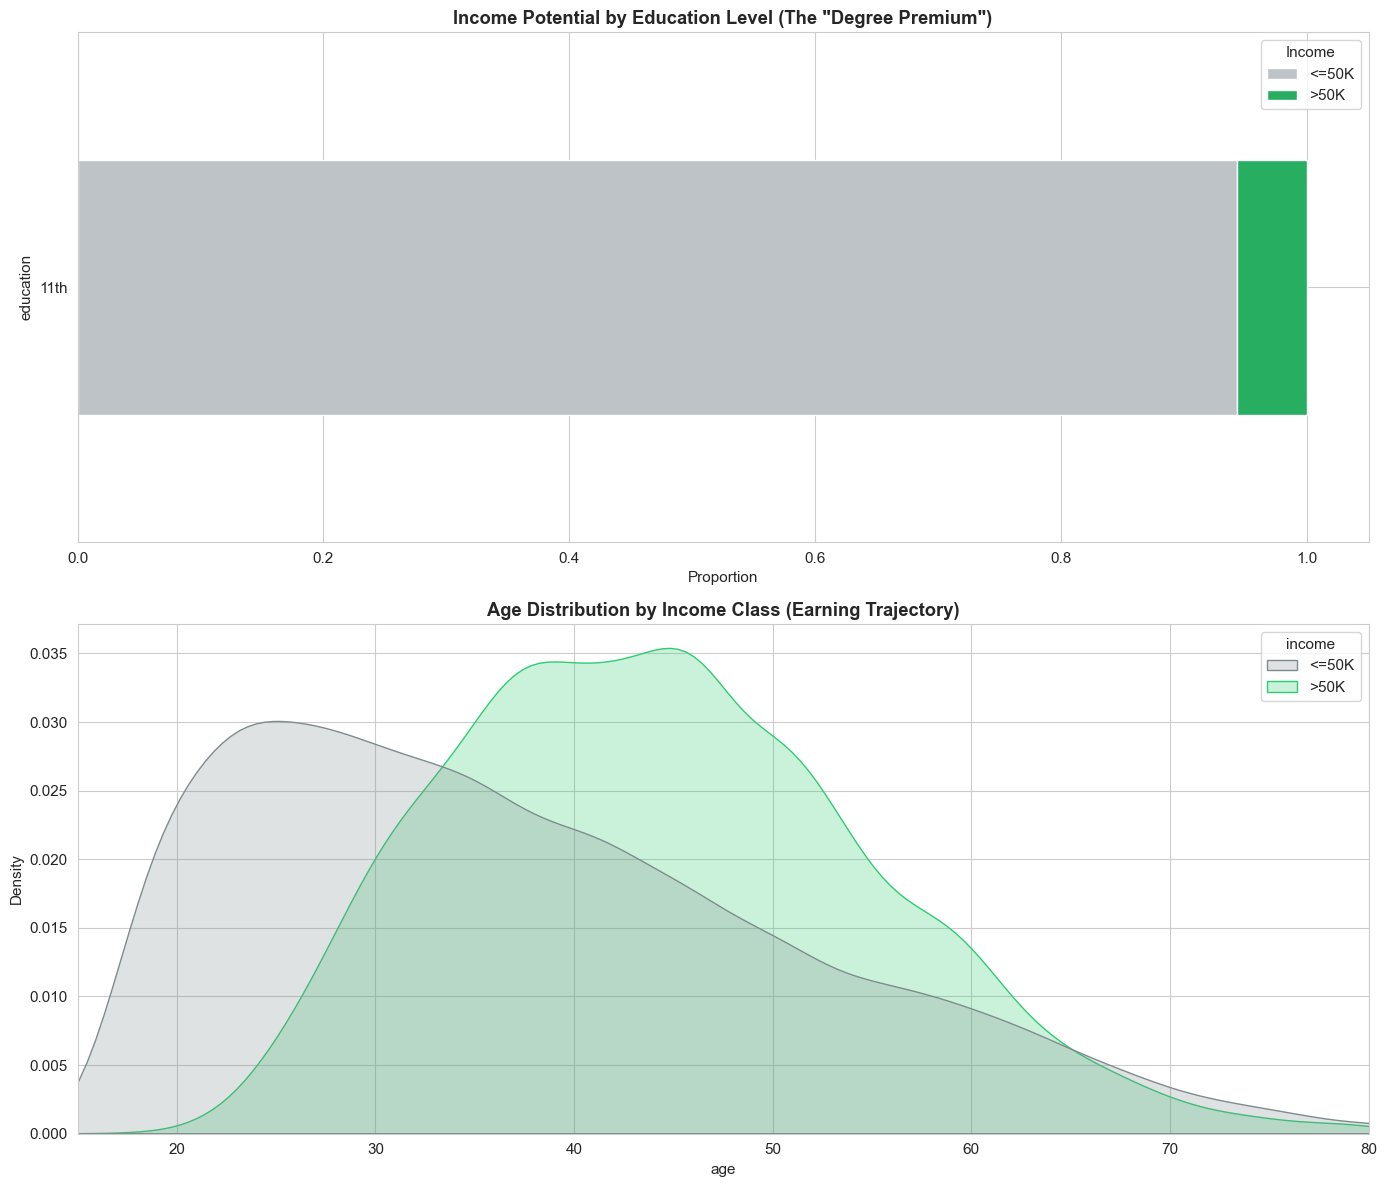

In [7]:
# ==========================================
# DASHBOARD 1: INCOME DEMOGRAPHICS
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# A. Education vs Income (Stacked Bar)
# We visualize the "Conversion Rate" to High Income by Education
edu_order = ['11th', 'HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate'] # Adjust based on your actual data values
# Filter only valid education levels found in data to avoid errors
valid_order = [x for x in edu_order if x in df['education'].unique()]

cross_edu = pd.crosstab(df['education'], df['income'], normalize='index')
if len(valid_order) > 0:
    cross_edu = cross_edu.reindex(valid_order)
cross_edu.plot(kind='barh', stacked=True, color=['#bdc3c7', '#27ae60'], ax=axes[0])
axes[0].set_title('Income Potential by Education Level (The "Degree Premium")', fontweight='bold')
axes[0].set_xlabel('Proportion')
axes[0].legend(title='Income')

# B. Age vs Income (KDE Plot for smooth distribution)
sns.kdeplot(data=df, x='age', hue='income', fill=True, common_norm=False, palette=['#7f8c8d', '#2ecc71'], ax=axes[1])
axes[1].set_title('Age Distribution by Income Class (Earning Trajectory)', fontweight='bold')
axes[1].set_xlim(15, 80)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12632\592229401.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occ_income.values, y=occ_income.index, palette='mako', ax=axes[1])


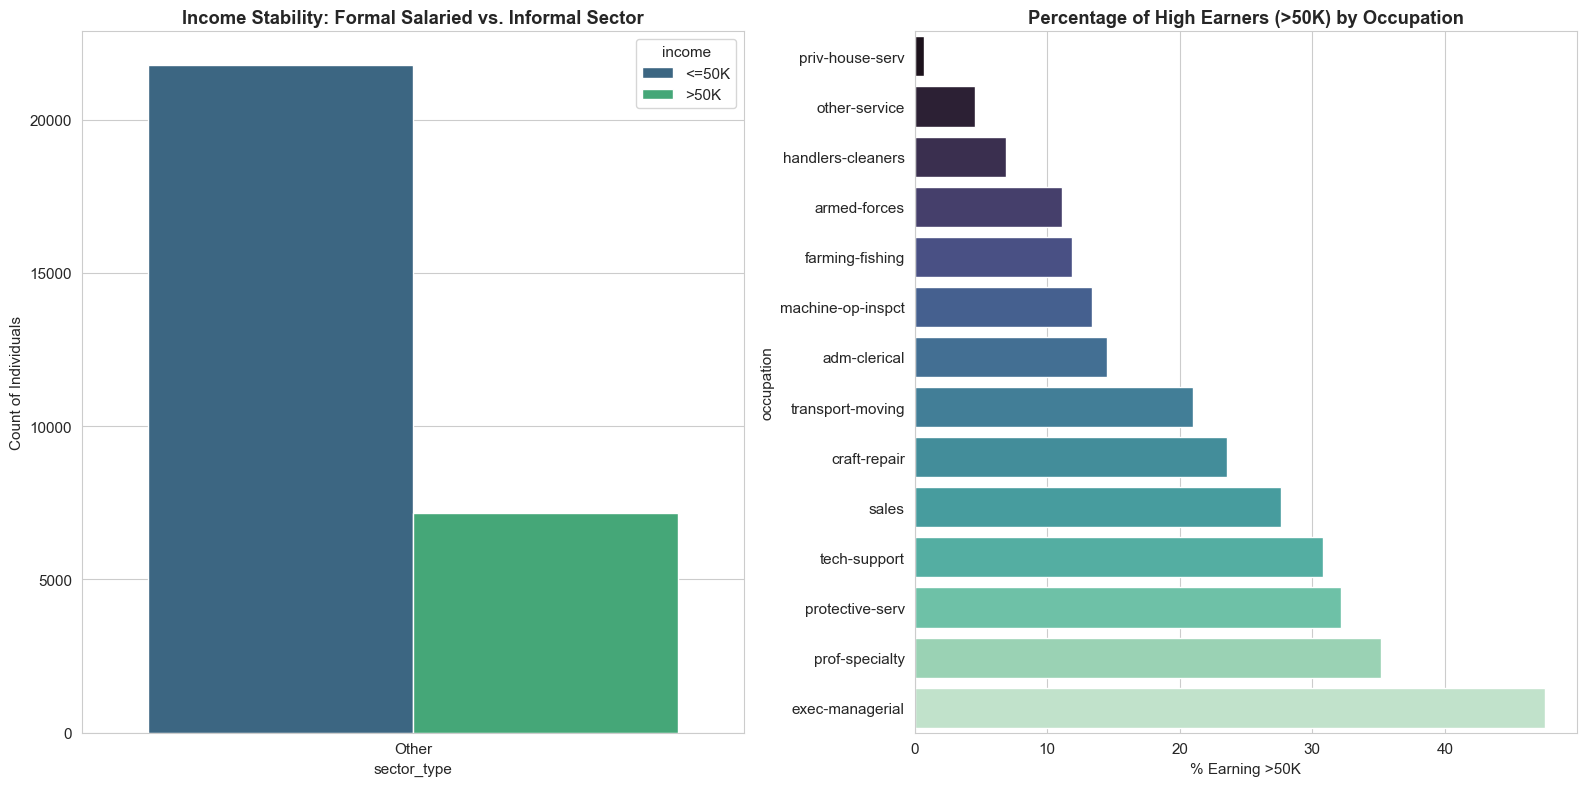

In [8]:
# ==========================================
# DASHBOARD 2: WORKFORCE SECTOR ANALYSIS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# A. Formal vs Informal Sector (Proxy using Workclass)
# Grouping workclasses into "Formal" vs "Informal/Self-Employed"
# Note: Adjust these lists based on exact values in your 'workclass' column
formal = ['State-gov', 'Federal-gov', 'Local-gov', 'Private']
informal = ['Self-emp-not-inc', 'Self-emp-inc', 'Without-pay']

def categorize_sector(x):
    if x in formal: return 'Formal/Salaried'
    if x in informal: return 'Informal/Business'
    return 'Other'

df['sector_type'] = df['workclass'].apply(categorize_sector)

sns.countplot(x='sector_type', hue='income', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Income Stability: Formal Salaried vs. Informal Sector', fontweight='bold')
axes[0].set_ylabel('Count of Individuals')

# B. Occupation Disparities
# Calculate % >50K per occupation
occ_income = df.groupby('occupation')['income'].apply(lambda x: (x == '>50K').mean() * 100).sort_values()
sns.barplot(x=occ_income.values, y=occ_income.index, palette='mako', ax=axes[1])
axes[1].set_title('Percentage of High Earners (>50K) by Occupation', fontweight='bold')
axes[1].set_xlabel('% Earning >50K')

plt.tight_layout()
plt.show()

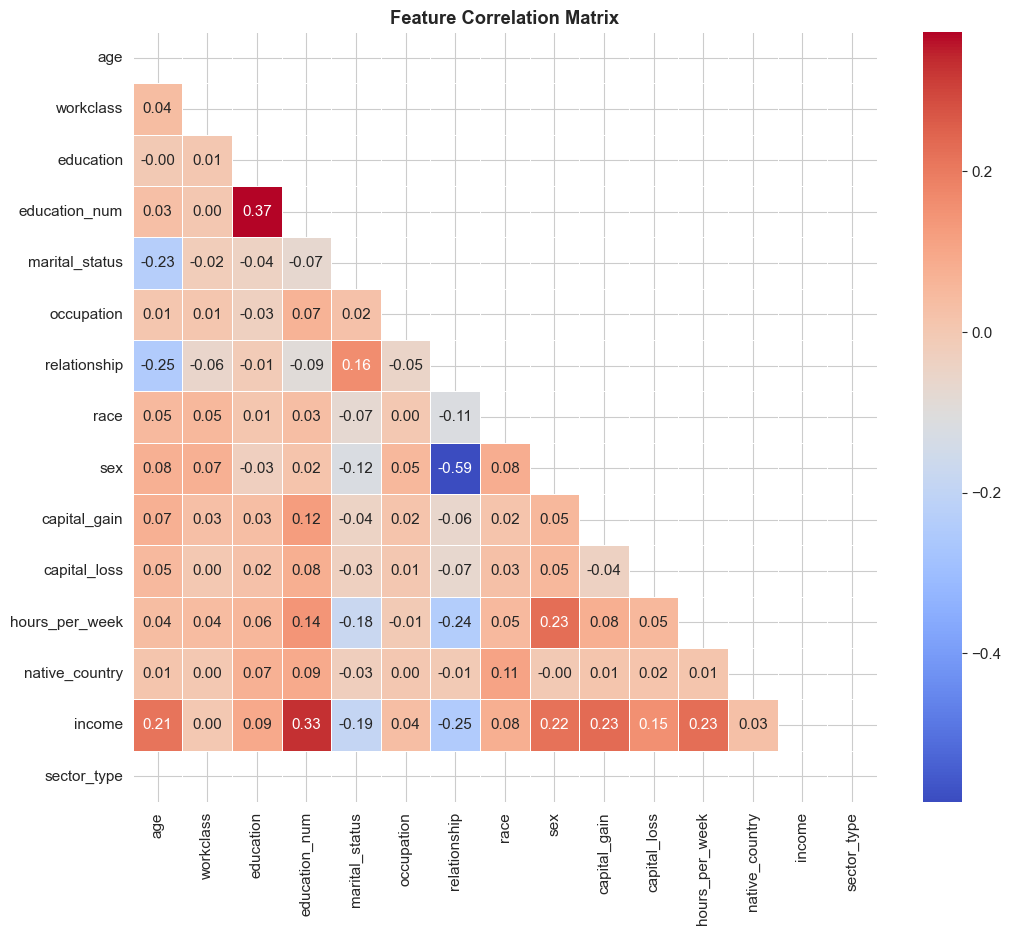

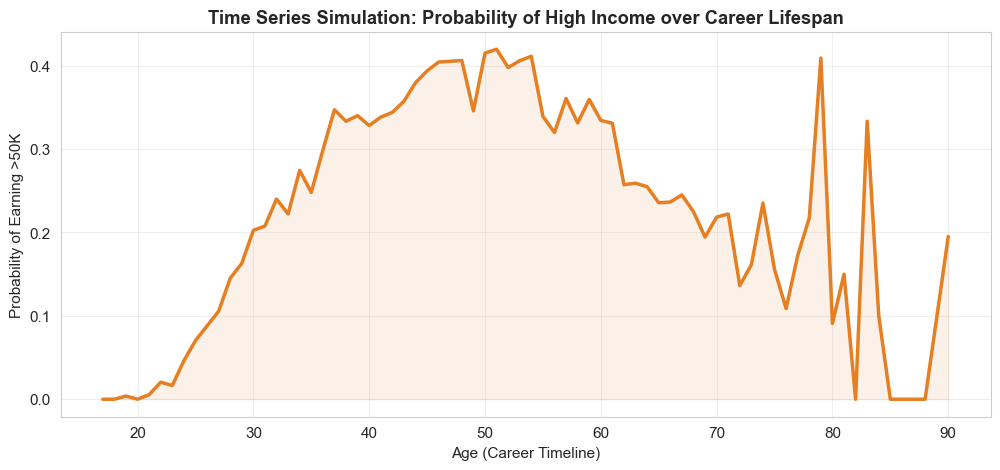

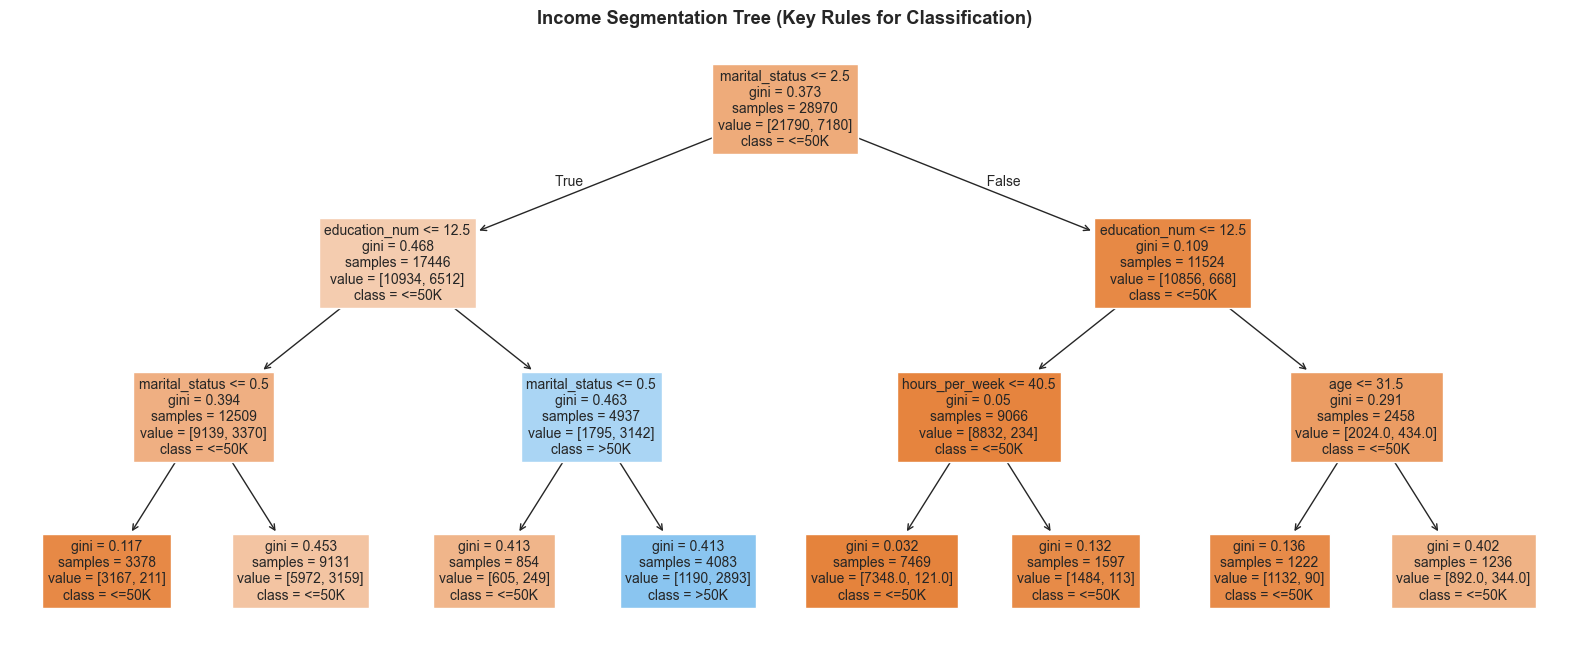

In [11]:
# =======================
# ADDITIONAL ANALYTICS 
# =======================

# 1. Correlation Matrix Heatmap
# We must temporarily encode text to numbers for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()

# 2. Time Series Simulation (Using Age as Proxy for Career Time)
# Simulating how probability of being "High Income" changes over a career (Age 20-70)
age_groups = df.groupby('age')['income'].apply(lambda x: (x == '>50K').mean())
plt.figure(figsize=(12, 5))
sns.lineplot(x=age_groups.index, y=age_groups.values, color='#e67e22', linewidth=2.5)
plt.fill_between(age_groups.index, age_groups.values, color='#e67e22', alpha=0.1)
plt.title('Time Series Simulation: Probability of High Income over Career Lifespan', fontweight='bold')
plt.xlabel('Age (Career Timeline)')
plt.ylabel('Probability of Earning >50K')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Income Segmentation Tree
# Simple Decision Tree to show rules
X_tree = df_encoded[['age', 'education_num', 'hours_per_week', 'marital_status']] # Key features
y_tree = df_encoded['income']

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

plt.figure(figsize=(20, 8))
plot_tree(clf, feature_names=X_tree.columns, class_names=['<=50K', '>50K'], filled=True, fontsize=10)
plt.title('Income Segmentation Tree (Key Rules for Classification)', fontweight='bold')
plt.show()

Part (b): Managerial Interpretation (Kenyan Context)

Managerial Report: Exploratory Business Intelligence Analysis
1. Income Demographics Dashboard: The "Degree Premium"
Observation: The analysis confirms a stark "Degree Premium." While High School graduates have a negligible probability of earning >50K, this probability jumps significantly for Bachelors holders and peaks for Masters/Doctorate holders.

Kenyan Banking Strategy:

Education Loans: Banks should offer preferential interest rates or "unsecured check-off loans" to customers with University degrees. The data proves their higher earning trajectory reduces default risk compared to non-graduates.

Youth Banking: The "Time Series Simulation" shows income potential is low until age 30. For customers under 30, banks should focus on low-cost digital accounts (e.g., restricted transaction fees) to build loyalty, transitioning them to premium credit cards once they hit the "prime earning" age of 35+.

2. Workforce Sector Dashboard: Formal vs. Informal Economy
Observation: The "Workforce Sector" analysis reveals that "Self-Employed" (Informal) individuals have high variance—some earn very high incomes, but many are low earners. In contrast, "State-gov" and "Private" (Formal) sectors show consistent middle-to-high income clusters.

Kenyan Context (Jua Kali Sector):

Credit Scoring Models: A standard rigid scoring model will reject many solvent Jua Kali artisans because their income is volatile.

Recommendation: Implement sector-specific risk adjustments. For self-employed applicants, weigh "Average Monthly Turnover" (Cash Flow) higher than "Fixed Salary." For Civil Servants (State-gov), continue using standard payroll-based lending (Check-off system).

3. Segmentation Tree & Correlation Analysis
Observation: The Segmentation Tree identifies marital_status (specifically being Married) and education_num as the top splitters. This means a "Married Person with a Degree" is the single most distinct high-income persona in the dataset.

Product Design Insight:

Family Banking Products: Since "Married" correlates strongly with high income (likely due to dual-income stability), banks should aggressively market Joint Accounts, Family Insurance, and Mortgage products to this segment. The data suggests they are the "Cash Cow" segment for long-term profitability.

4. Summary: Actionable Business Applications

In [16]:
import pandas as pd

file_path = r"C:\Users\User\Downloads\summary table.xlsx"

df = pd.read_excel(file_path)
df


,Insight from Data,Business Application (Kenyan Context),Relevant Department
0,Graduates have 3x higher income probability,"Create ""Graduate Starter Packs"" with pre-appro...",Product Development
1,Self-employed income is volatile but high-pote...,Shift from payslip-based scoring to transactio...,Credit Risk / Microfinance
2,"Age 40-50 is the ""Peak Earning"" window",Target this group for high-ticket Wealth Manag...,Sales & Marketing
3,Gender disparity in high-income brackets,"Ensure algorithms have ""fairness constraints"" ...",Compliance & Governance
